# Работа с целевой переменной

## Цель работы

Познакомиться с основными приемами обработки данных в отношении к целевой переменной: дискретизация, отбор признаков, устранение дисбаланса классов.

## Содержание работы

1. Загрузите первый датасет для регрессии и познакомьтесь с его структурой.
2. Постройте простую модель регрессии и оцените ее качество.
3. Отберите признаки, наиболее сильно влияющие на значение целевой переменной.
4. Постройте модель на оставшихся данных и оцените ее качество.
5. Загрузите второй датасет для регрессии и постройте распределение целевой переменной.
6. Сгруппируйте значения целевой переменной в категории. Постройте получившееся распределение.
7. Загрузите датасет для классификации. Постройте распределение целевой переменной.
8. Разделите датасет на тестовую и обучающую выборки, постройте и оцените baseline модель классификации.
9. Постройте ту же модель с применением весов классов. Сравните ее качество, сделайте выводы.
10. Выравняйте распределение классов путем оверсемплинга с повторением

## Методические указания

В предыдущих работах мы занимались предобработкой разных типов данных, ориентируясь на сами характеристики этих данных: их распределения, аномалии, шкалы и так далее. То есть, мы ориентировались на информацию, которую содержат эти переменные изолированно. Однако, для целей моделирования нас в первую очередь интересует то, как тот или иной признак влияет на значение целевой переменной. 

В данной работе мы познакомимся с основными операциями обработки данных, которые принимают во внимание соотношение признаков и целевой переменной. Среди них преобразования самой целевой переменной, отбор признаков, работа с несбалансированными датасетами.

### Отбор признаков по важности

В этой работе мы будем практиковаться на наборах данных с сайте OpenML. Это один их крупных открытых репозиториев датасетов, моделей и алгоритмов машинного обучения, наподобие Kaggle, отличающийся удобным поиском с возможностью фильтрации по датасетам. Что еще более удобно, интеграция с этим репозиторием встроена в библиотеку sklearn, так что можно воспользоваться одной функцией для загрузки датасета.

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import KBinsDiscretizer

plt.style.use('seaborn-v0_8-darkgrid')

Для загрузки датасета нам понадобится указать его имя. Если вы ищете датасет на сайте, то его имя указано в заголовке страницы датасета. Для первого примера мы возьмем датасет mtp, содержащий фармокологические данные. Этот датасет подходит для наших целей: в нем довольно много признаков, не все и которых очень показательны для значения целевой переменной.

In [66]:
df = fetch_openml("mtp", version=1)
df.data.head()

,oz1,oz2,oz3,oz4,oz5,oz6,oz7,oz8,oz9,oz10,...,oz193,oz194,oz195,oz196,oz197,oz198,oz199,oz200,oz201,oz202
0,0.076923,0.325000,0.035088,0.200000,0.162112,0.194562,0.003900,0.060606,0.166667,0.045872,...,0.013874,0.071602,0.056880,0.179132,0.505899,0.039213,0.091327,0.321109,0.127564,0.188387
1,0.230769,0.375000,0.042105,0.333333,0.464191,0.622795,0.077623,0.373737,0.305556,0.192661,...,0.006342,0.186056,0.287438,0.384236,0.683820,0.326584,0.117990,0.456665,0.475618,0.401935
2,0.269231,0.437500,0.052632,0.333333,0.506556,0.531840,0.054374,0.212121,0.333333,0.229358,...,0.005018,0.179544,0.117431,0.384550,0.499219,0.204885,0.155967,0.360441,0.497968,0.407742
3,0.153846,0.357143,0.039474,0.266667,0.352880,0.394131,0.019654,0.171717,0.277778,0.091743,...,0.004801,0.091771,0.145349,0.243064,0.630533,0.023469,0.124430,0.336023,0.134458,0.252258
4,0.153846,0.357143,0.039474,0.266667,0.350523,0.320546,0.013154,0.101010,0.166667,0.110092,...,0.011166,0.130755,0.067583,0.250832,0.516053,0.111398,0.125693,0.332113,0.295913,0.253548


Теперь мы можем оперировать этим датасетом как и любым другим. У датасетов OpenML общий интерфейс: они представляют собой словарь со стандартными ключами. В частности, признаки хранятся по ключу data, а значения целевой переменной - по ключу target. Таким образом, наш датасет уже не нужно разделять на X и y.

Давайте построим распределение целевой переменной:

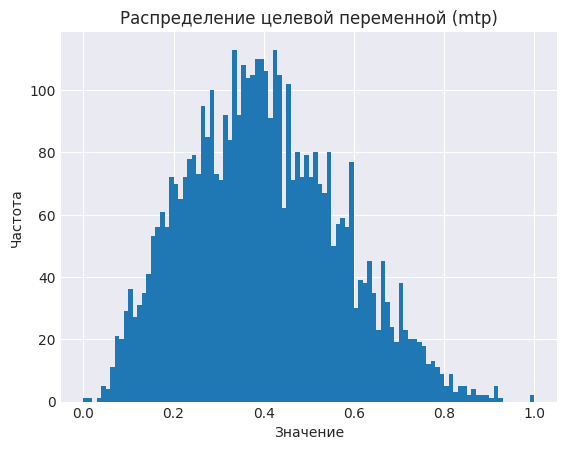

In [67]:
plt.hist(df.target, 100)
plt.title("Распределение целевой переменной (mtp)")
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.show()

Мы видим, что целевая переменная представляет собой численное значение, что определяет задачу моделирования как регрессию. Кроме того, график показывает, что распределение имеет форму, сходную с нормальным.

Это довольно типичное распределение непрерывной величины в естественных данных. Ничего особенно примечательного здесь нет. Мы его построили справочно, более подробно с распределением целевой переменной будем работать в следующих пунктах.

### Построение базовой (baseline) модели

Для того, чтобы оценивать эффективность тех или иных методов обработки данных, желательно понимать, как они влияют на эффективность обучаемых моделей. Для этого до начала любых преобразований данных нужно построить базовую простую модель и оценить ее эффективность. Такая базовая модель часто называется простой baseline или базовой моделью. Такая модель позволяет выбрать те способы изменения исходного датасета, которые увеличивают его предсказательную силу, то есть работают на увеличение точности моделей. Именно с бейзлайном мы будем сравнивать эффективность моделей после преобразования данных.

В любом случае, нам потребуется разделить выборку на обучающую и тестовую для несмещенного оценивания уровня эффективности модели. Для еще более точной оценки, можно использовать перекрестную проверку, можете сделать это самостоятельно, мы же воспользуемся обычным разбиением:

In [68]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

В качестве базовой модели лучше выбрать простую (вычислительно) модель, которая, желательно, обладает высокой интерпретируемостью. Для этого лучше всего подходят линейные модели и деревья решений. В данном случае, воспользуемся моделью линейной регрессии:

In [69]:
baseline = LinearRegression()
baseline.fit(X_train, y_train)
bl_score = baseline.score(X_test, y_test)
bl_score

-1.6511340764956186

Базовая модель демонстрирует очень низкий уровень эффективности, хуже случайности, хуже предсказания среднего значения. Если бы мы продиагностировали ее, мы бы поняли, что проблема в очень высокой вариативности модели. Самая простая модель уже "переобучается" на наших данных. Это происходит потому, что в данных очень много признаков, каждый их которых добавляет одну степень свободы модели (добавляет один обучаемый коэффициент), что увеличивает её сложность. При этом далеко не все эти признаки нужны для предсказания значения целевой переменной. Как правило, при большом количестве признаков, большинство не несет полезной информации.

Еще будет полезно изобразить линию регрессии на графике, чтобы визуально убедиться в ее низком качестве:

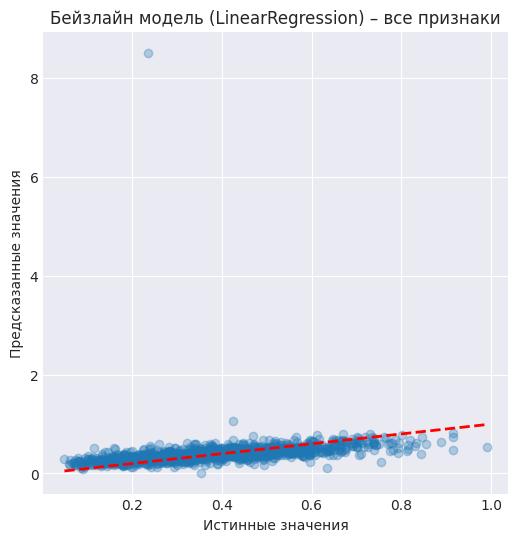

In [70]:
y_pred_baseline = baseline.predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_baseline, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.title("Бейзлайн модель (LinearRegression) – все признаки")
plt.grid(True)
plt.show()

### Определение относительной важности признаков

Для улучшения работы модели нам нужно избавиться от неинформативных, лишних признаков в датасете. Существует множество стратегий, как можно это сделать. Например, мы можем исключать признаки по одному и следить, исключение каких лучше всего влияет на модель. Однако, эта стратегия, называемая "рекурсивное исключение признаков", будет слишком медленно работать, так как у нас больше 200 признаков и чтобы исключить хотя бы один, нам нужно обучить более 200 моделей и так далее.

Также можно попробовать рекурсивное добавление признаков. В этом случае мы выбираем признак, который дает наибольшую эффективность в задаче парной регрессии. После этого также перебором подбираем к нему второй и так далее. Этот способ будет ненамного быстрее и также потребует большого количества вычислительных ресурсов.

Можно использовать парные статистические критерии, которые оценивают степень взаимного влияния двух переменных. Это, например, хи-квадрат, тест Фишера для задач классификации, коэффициент корреляции для регрессии. В данном случае, можно построить коррелограмму, то есть матрицу коэффициентов парной корреляции. Или просто посчитать корреляцию каждого признака с целевой переменной. После этого останется только выбрать те признаки, у которых такой коэффициент выше.

Как мы говорили в лекциях, коэффициенты обученной модели линейной регрессии имеют очень схожий смысл. Можно посмотреть на коэффициенты обученной модели и выбрать те признаки, коэффициенты при который сильнее отличаются от 0. Однако, этот способ, как и оценка коэффициента корреляции, учитывает только линейную связь между конкретным признаком и целевой переменной.

Можно воспользоваться информацией, которую дает обученная нелинейная модель. Мы уже говорили, что построение, например, дерева решений позволяет оценить относительную важность признаков. Причем эта важность будет учитывать не только линейное, но и более сложное нелинейное и совместное влияние факторов. Плюс, библиотека sklearn позволяет получить эту информацию автоматически, после обучения модели, нам не нужно специально что-то отдельно вычислять.
Так можно узнать, какие из них оказывают наибольшее влияние на значение целевой переменной.

В данном примере мы используем даже не отдельное дерево, которое может очень сильно переобучиться на нашей выборке, а его более сильную и робастную ансамблевую версию - случайный лес:

In [71]:
rf = RandomForestRegressor(n_estimators=15).fit(X_train, y_train)

По сути, случайный лес - это набор деревьев, каждый из которых видит случайную часть выборки. Более подробно про ансамбли моделей мы поговорим далее в курсе. Сейчас важно, что при помощи свойства feature_importances_ можно получить информацию о важности признаков. Удобнее всего изобразить эту информацию на графике в отсортированном виде:

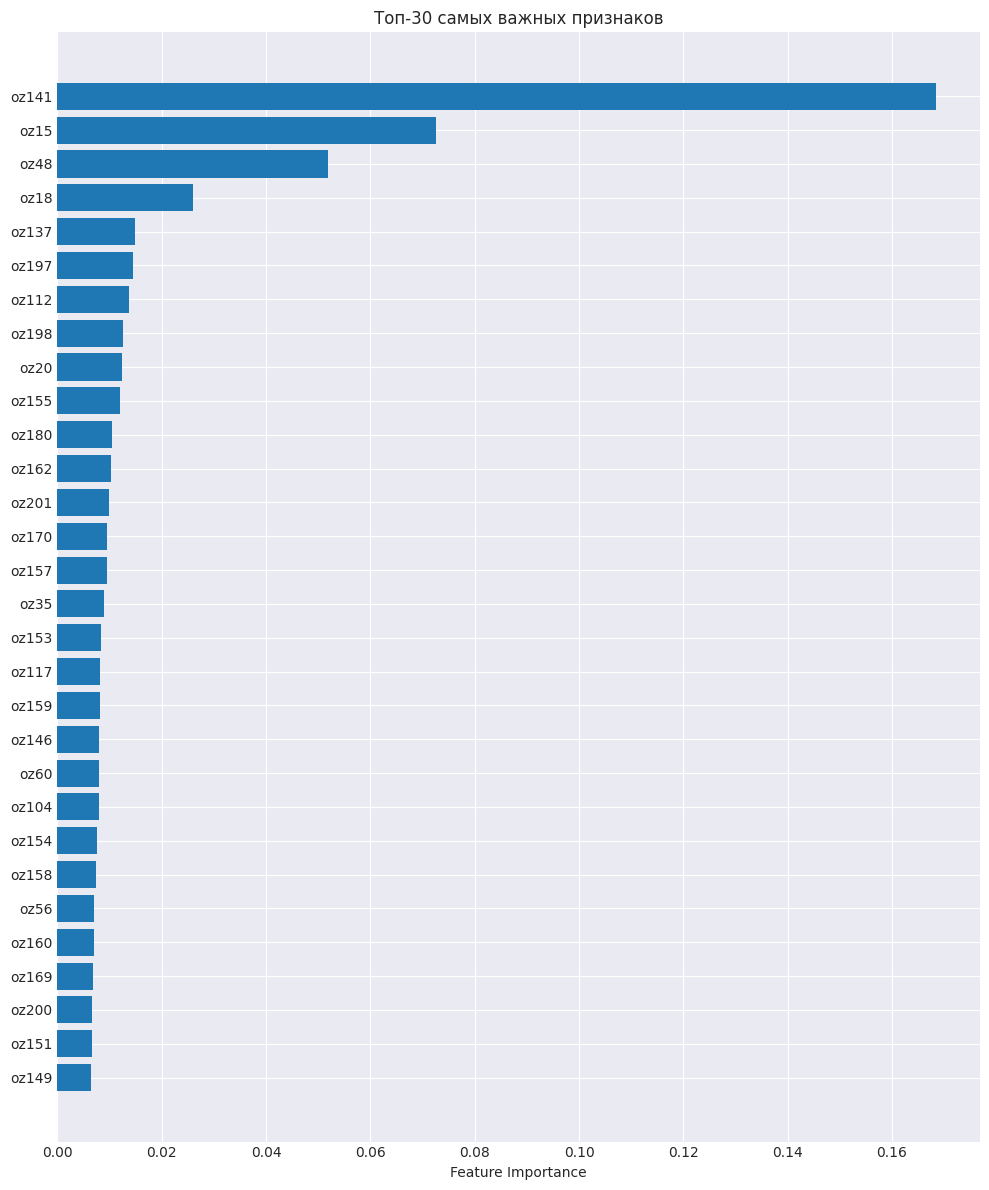

In [72]:
sort = rf.feature_importances_.argsort()
plt.figure(figsize=(10, 12))
plt.barh(df.data.columns[sort][-30:], rf.feature_importances_[sort][-30:])
plt.xlabel("Feature Importance")
plt.title("Топ-30 самых важных признаков")
plt.tight_layout()
plt.show()

Мы получим столбчатый график, на котором по вертикали отложены все наши признаки, они подписаны слева вдоль вертикальной оси, по горизонтали - отложена относительная важность данного признака. Это условное число, которое показывает, насколько информативен данный признак для предсказания значения целевой переменной.

Из-за того, что у нас более 200 признаков, подписи мало читаются. Можете самостоятельно построить более читаемый график, отобрав, например, только 30 самых значимых признаков. Мы можем просто вывести значимость самых важных колонок датасета:

In [73]:
rf.feature_importances_[sort][-10:]

array([0.01191366, 0.01233754, 0.01262559, 0.01375932, 0.01449697,
       0.01494877, 0.02608739, 0.05178519, 0.0726197 , 0.16843514])

Обратите внимание, из-за того, что для построения графика мы сортировали массив по возрастанию, самые значимые признаки - в конце. Таким образом, нам нужны, например, 10 последних элементов в этом массиве.

Более интересна и полезна для нас информация о названиях самых важных признаков. Их тоже можно вывести:

In [74]:
df.data.columns[sort][-10:]

Index(['oz155', 'oz20', 'oz198', 'oz112', 'oz197', 'oz137', 'oz18', 'oz48',
       'oz15', 'oz141'],
      dtype='str')

Мы получаем соответствующее количество признаков, оказывающих наибольшее влияние на целевую переменную. Обратите внимание, что самые важные признаки будут в конце списка. Но для дальнейших целей нам не важен порядок колонок.

Теперь мы можем использовать эту информацию для удаления лишних данных из датасета. Количество самых важных признаков мы выбираем сами. Зачастую для этого используют "метод локтя". Можете самостоятельно попробовать разное количество признаков, мы сейчас возьмем 20:

In [75]:
trimmed = df.data[df.data.columns[sort][-20:]]
trimmed.head()

,oz146,oz159,oz117,oz153,oz35,oz157,oz170,oz201,oz162,oz180,oz155,oz20,oz198,oz112,oz197,oz137,oz18,oz48,oz15,oz141
0,0.011997,0.929724,0.000000,0.052296,0.0,0.000000,0.866163,0.127564,0.319206,0.002655,0.752291,0.000000,0.039213,0.000000,0.505899,0.000000,0.0625,0.312855,0.000000,0.041308
1,0.025932,0.944542,0.311793,0.060922,0.4,0.000281,0.866069,0.475618,0.306084,0.002581,0.745984,0.242424,0.326584,0.222222,0.683820,0.278945,0.0625,0.297041,0.282828,0.212274
2,0.007666,0.946121,0.000000,0.072628,0.0,0.001852,0.866224,0.497968,0.406309,0.002722,0.753298,0.388889,0.204885,0.000000,0.499219,0.000000,0.1250,0.288557,0.388889,0.063643
3,0.021463,0.945087,0.000000,0.054593,0.1,0.000158,0.865988,0.134458,0.327848,0.002473,0.767469,0.095238,0.023469,0.000000,0.630533,0.039437,0.0000,0.310692,0.111111,0.031193
4,0.006780,0.941644,0.000000,0.045400,0.0,0.000037,0.866283,0.295913,0.329857,0.002810,0.741548,0.260870,0.111398,0.000000,0.516053,0.000000,0.0625,0.286581,0.304348,0.063643


Не рекомендуется модифицировать исходную переменную, лучше создать новую копию датасета, в которую перенести только нужные колонки. Конечно, это нужно сделать и в обучающей и в тестовой части выборки. Либо, в исходном общем датасете, а затем повторить разбиение еще раз. Теперь все готово для того, чтобы построить модель на урезанном датасете:

In [76]:
X_train, X_test, y_train, y_test = train_test_split(trimmed, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train, y_train)

print(f"Базовая модель R²: {bl_score:.4f}")
print(f"Модель после отбора 20 признаков R²: {better.score(X_test, y_test):.4f}")

Базовая модель R²: -1.6511
Модель после отбора 20 признаков R²: 0.3565


Мы используем тот же класс моделей - линейную регрессию - чтобы различия в метрике были сопоставимы. И мы получаем гораздо более качественную модель. Метрика уже положительна, что свидетельствует о большом росте точности.

Можно изобразить график модели и визуально, чтобы убедиться в том, что он разительно отличается от графика, который мы получили ранее:

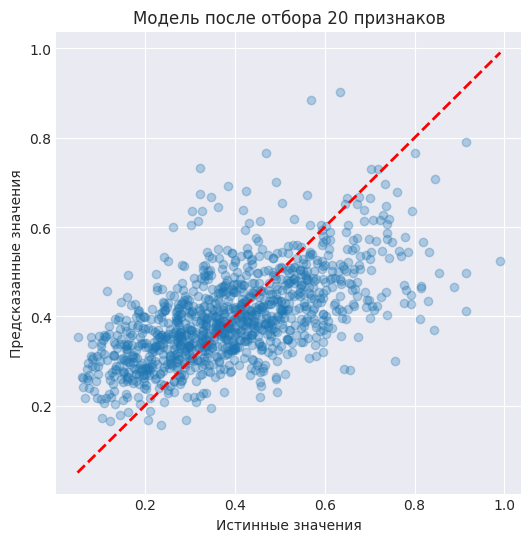

In [77]:
y_pred_better = better.predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_better, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.title("Модель после отбора 20 признаков")
plt.grid(True)
plt.show()

Регрессия еще далека от идеала, но уже значительно лучше случайности и показывает некоторый уровень эффективности, который может быть приемлемым в зависимости от прикладной задачи.

Мы, конечно, оценивали качество модели только по одной метрике. Можете самостоятельно сравнить значение других метрик качества регрессии на этих двух моделях. Убедитесь, что вторая модель лучше по любой выбранной метрике.

В данном примере сокращение количества столбцов в 10 раз, с 200 до 20, пошло только на пользу модели, так как избавило ее от лишних признаков, которые искусственно завышают сложность и вариативность функции гипотезы за счет введения большого числа коэффициентов. Другими словами, отбор признаков по важности оказывает регуляризирующее действие на модель.

### Автоматизация отбора признаков

Конечно, отбор признаков - это довольно стандартная процедура при моделировании. В предыдущем примере мы все делали руками. Однако, в библиотеке sklearn есть встроенные средства выбора признаков. Познакомьтесь с ними в документации. Sklearn умеет автоматизировать как рекурсивное исключение и добавление признаков, и отбор по статистическим критериям, так и отбор по результатам обучения модели. 

Давайте напомним себе о форме датасета:

In [78]:
df.data.shape

(4450, 202)

Исходно у нас присутствует 202 признака. В sklearn есть специальный объект, SelectFromModel, который находится в пакете feature_selection. Познакомьтесь с документацией к этому классу и к другим классам из данного пакета. Работа с ними напоминает работу с другими классами преобразования данных в том плане, что используется подход fit-transform:

In [79]:
from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(RandomForestRegressor(n_estimators=15)).fit(df.data, df.target)
X_trimmed = sfm.transform(df.data)
X_trimmed.shape

(4450, 52)

Обратите внимание, что мы передаем в этот объект вид модели машинного обучения, на основе которой будет производиться отбор признаков. При этом, методы fit() объекта SelectFromModel в том числе произведет обучение модели. Помните об этом, если используете ресурсоемкую модель. Данный объект можно настроить для использования уже обученной модели, без повторного запуска обучения.

Также обратите внимание, что мы используем данное преобразование на всем датасете. В дальнейшем мы опять разобьем его на обучающую и тестовую выборки. Однако, так как объект преобразования SelectFromModel сохраняется и "запоминает" нужные признаки, мы можем обучить его и уже после разбиения. В таком случае, метод transform() нужно будет вызвать и для обучающей и для тестовой выборки отдельно. Преобразование будет скоординированным.

Посмотрим, как данный код преобразовал данные. У нас осталось 55 признаков. Это больше, чем мы использовали в прошлый раз. Решение об этом принимает сам алгоритм SelectFromModel. Его, конечно, тоже можно настроить. Но сейчас давайте проверим, как данная обработка скажется на эффективности модели. Для этого построим уже третью модель на этом датасете:

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X_trimmed, df.target, test_size=0.25, random_state=42)

auto_model = LinearRegression()
auto_model.fit(X_train, y_train)

print(f"Базовая модель R²: {bl_score:.4f}")
print(f"Автоматический отбор признаков (SelectFromModel) R²: {auto_model.score(X_test, y_test):.4f}")

Базовая модель R²: -1.6511
Автоматический отбор признаков (SelectFromModel) R²: 0.4325


Мы видим еще большее улучшение по метрикам. Увеличение количества признаков до 55 не привело к переобучению модели. То же можно видеть и по графику.

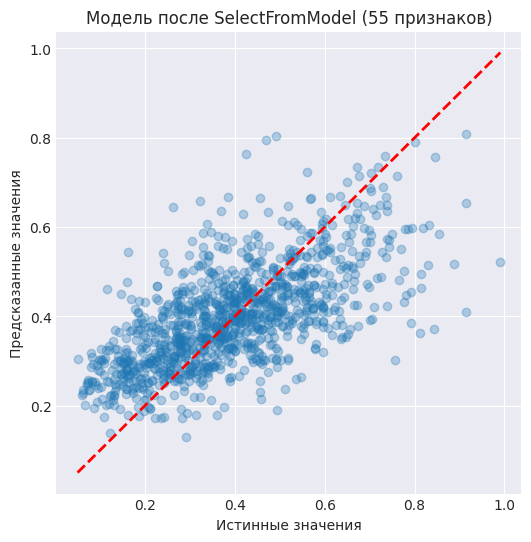

In [81]:
y_pred_auto = auto_model.predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_auto, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.title("Модель после SelectFromModel (55 признаков)")
plt.grid(True)
plt.show()

Найдите самостоятельно, самое оптимальное количество признаков, которые следует оставить в модели для достижения наиболее высокой тестовой эффективности.

### Устранение дисбаланса классов

Одна из самых частых проблем при построении моделей классификации на реальных данных - дисбаланс классов. Это ситуация, когда в датасете присутствует очень разное количество объектов, принадлежащих разным классам. Другими словами, это неравномерность распределения значений целевой переменной. При этом проблемой такой дисбаланс становится, когда объектов одного класса в несколько раз, а то и десятков раз больше чем другого. На практике, соотношение, например, 100 к 1 не является редкостью.

Это может быть проблемой при обучении моделей потому, что при подборе весов модель будет чаще видеть в обучающих примерах объекты мажоритарного или мажоритарных классов (то есть таких, объектов которых значительно больше). И их влияние на изменение параметров функции гипотезы будет превалировать над влиянием объектов миноритарных классов. В итоге модель может одновременно недообучиться на мажоритарных классах и переобучиться на миноритарных. При анализе результатов моделирования эту проблему проще всего выявить при рассмотрении отчета о классификации - объекты миноритарных классов распознаются значительно хуже.

Давайте обратимся к примеру. Возьмем датасет результатов психологического моделирования:

In [82]:
df_class = fetch_openml("balance-scale", version=1)
df_class.data.head()

,left-weight,left-distance,right-weight,right-distance
0,1,1,1,1
1,1,1,1,2
2,1,1,1,3
3,1,1,1,4
4,1,1,1,5


Этот набор данных не требует технической предварительной обработки для построения модели, поэтому сразу визуализируем распределение целевой переменной:

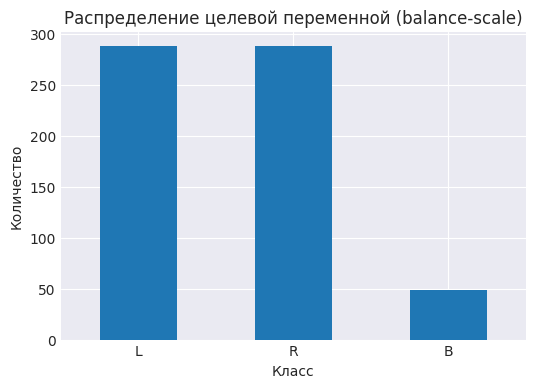

class
L    288
R    288
B     49
Name: count, dtype: int64


In [83]:
plt.figure(figsize=(6, 4))
df_class.target.value_counts().plot(kind='bar')
plt.title("Распределение целевой переменной (balance-scale)")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.show()

print(df_class.target.value_counts())

Мы видим, что объекты объединены в три класса, называемые "B", "R" и "L". Причем, объектов класса "B" примерно в шесть раз меньше, чем каждого из двух других. Это - миноритарный класс, а два других - мажоритарные. Для построения базовой модели, как всегда разделим выборку:

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    df_class.data, df_class.target, test_size=0.25,
    random_state=42, stratify=df_class.target
)

Обратите внимание, что при разделении несбалансированных выборок за счет случайных ошибок мы можем существенно сместить форму этого распределения. Вполне вероятно, что объекты миноритарного класса вообще по прихоти случайности не попадут в тестовую выборку, или попадут в еще меньшей доле. Или наоборот. Этого следует избегать, так как для адекватного оценивания качества модели, обучающая и тестовая выборки должны быть как можно более сходными по своим статистическим характеристикам. Все статистики в выборке мы проконтролировать не можем, но хотя бы должны убедиться, что распределение целевой переменной будет сходным.

Для этого применяют особый прием - стратификацию выборки. В функцию train_test_split можно передать специальный аргумент, который заставит ее учитывать распределение объектов по данной переменной. В нашем случае, мы используем целевую переменную для стратификации. Это гарантирует, что две подвыборки после разделения сохранят форму данного распределения. Убедиться можно на графике построив гистограмму значений целевой переменной в одной из выборок после разделения:

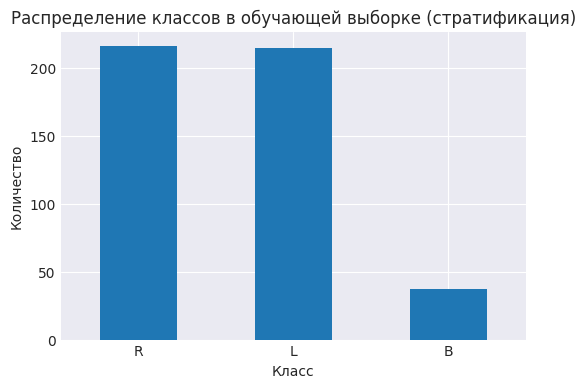

In [85]:
plt.figure(figsize=(6, 4))
y_train.value_counts().plot(kind='bar')
plt.title("Распределение классов в обучающей выборке (стратификация)")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.show()

Теперь мы готовы построить базовую модель. Так как перед нами задача классификации, в качестве базовой выберем логистическую регрессию:

In [86]:
baseline_clf = LogisticRegression(max_iter=1000)
baseline_clf.fit(X_train, y_train)
bl_score_clf = baseline_clf.score(X_test, y_test)
print(f"Базовая точность: {bl_score_clf:.4f}")
print("\nОтчет о классификации:")
print(classification_report(y_test, baseline_clf.predict(X_test)))
print("Матрица ошибок:")
print(confusion_matrix(y_test, baseline_clf.predict(X_test)))

Базовая точность: 0.8599

Отчет о классификации:
              precision    recall  f1-score   support

           B       0.00      0.00      0.00        12
           L       0.87      0.92      0.89        73
           R       0.86      0.94      0.90        72

    accuracy                           0.86       157
   macro avg       0.58      0.62      0.60       157
weighted avg       0.80      0.86      0.83       157

Матрица ошибок:
[[ 0  6  6]
 [ 1 67  5]
 [ 0  4 68]]


Базовая модель дает примерно 86% точности.

Опять же, можно оценивать модель и по другим метрикам. Более того, постановка задачи будет диктовать нам, какая метрика будет целевой, то есть на какую метрику мы должны ориентироваться в первую очередь при выборе и оценке моделей.

Так как мы исследуем проблему дисбаланса классов, обязательно надо построить отчет о классификации.

На нем мы видим, что эффективность модели действительно разнится для разных классов. Фактически, модель вообще ни разу не распознала правильно объект миноритарного класса. Поэтому невзвешенная оценка качества модели на самом деле ближе к отметке в 60%. Это не очень удовлетворительный результат.

Давайте посмотрим, удастся ли нам улучшить данную модель. Как всегда, есть несколько стратегий борьбы с дисбалансом классов. Здесь рассмотрим два: взвешивание классов и ресемплинг выборки.

Главная проблема дисбаланса классов в том, что модель недостаточно учитывает объекты миноритарных классов. Можно относительно просто это исправить, при обучении модели, придав больший "вес" таким редким объектам. Это называется взвешивание классов. Для начала надо рассчитать "важность" или вес класса, который будет обратно пропорционален его доле в выборке. Можно сделать это и руками, но в библиотеке sklearn есть встроенная функция для этого:

In [87]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), class_weights))
class_weights

{'B': np.float64(4.216216216216216),
 'L': np.float64(0.7255813953488373),
 'R': np.float64(0.7222222222222222)}

Мы видим, что вес миноритарного класса действительно гораздо больше, чем двух других. Эту информацию можно передать непосредственно модели машинного обучения через параметр конструктора:

In [88]:
weighted_clf = LogisticRegression(class_weight=class_weights, max_iter=1000)
weighted_clf.fit(X_train, y_train)
print(f"Базовая точность: {bl_score_clf:.4f}")
print(f"Взвешенная модель точность: {weighted_clf.score(X_test, y_test):.4f}")
print("\nОтчет о классификации:")
print(classification_report(y_test, weighted_clf.predict(X_test)))

Базовая точность: 0.8599
Взвешенная модель точность: 0.9236

Отчет о классификации:
              precision    recall  f1-score   support

           B       0.61      0.92      0.73        12
           L       0.97      0.92      0.94        73
           R       0.96      0.93      0.94        72

    accuracy                           0.92       157
   macro avg       0.85      0.92      0.87       157
weighted avg       0.94      0.92      0.93       157



Такая модель будет сильнее изменять свои веса в ответ на объект миноритарного класса, пропорционально весу этого класса. На самом деле все немного сложнее, так как обучение идет методом пакетного градиентного спуска, в котором на каждом шаге обрабатывается несколько объектов выборки, но смысл именно в этом.

Мы видим, что точность модели возросла с 86% до 92%. Это очень существенное увеличение эффективности. Причем обратите внимание, что оценивали модель мы на той же тестовой выборке, в которой сохранено исходное неравномерное распределение. То есть это естественное повышение качества. При этом точность модели на этом миноритарном классе все равно немного ниже, чем на других. Это тоже естественно. Но разница уже далеко не такая огромная.

### Oversampling

Но что делать, если конкретная модель не поддерживает взвешивание классов? Или по какой-то другой причине, такой способ либо не подходит, либо не дает нужного эффекта? Можно использовать ресемплинг - то есть случайную выборку из исходного датасета с выравниванием распределения по классам. Есть две стратегии. Оверсемплинг - это когда мы семплируем в выборку больше объектов миноритарного класса с повторениями. Андерсемплинг - это исключение случайных объектов мажоритарных классов до выравнивания распределения. Есть гибридный подход - когда мы делаем и то и другое в определенных пропорциях. Кроме того, есть продвинутые техники генерации или аугментации данных для выравнивания распределения.

Покажем на простом примере как работает оверсемплинг. Подсчитаем точное количество объектов каждого класса в обучающей выборке:

In [89]:
y_train.value_counts()

class
R    216
L    215
B     37
Name: count, dtype: int64

Видим, что объектов миноритарного класса всего 37 против 216 - мажоритарного.

Для дальнейших манипуляций нам будет удобно объединить матрицу признаков и вектор целевой переменной в один датафрейм:

In [90]:
X_train_df = X_train.copy()
X_train_df["target"] = y_train

Теперь мы семплируем недостающее количество объектов миноритарного класса из нашего датасета с повторениями:

In [91]:
minority_class = y_train.value_counts().idxmin()
majority_count = y_train.value_counts().max()
minority_count = y_train.value_counts().min()

n_to_sample = majority_count - minority_count

if n_to_sample > 0:
    oversampled = X_train_df[X_train_df.target == minority_class].sample(
        n=n_to_sample, replace=True
    )
else:
    oversampled = pd.DataFrame(columns=X_train_df.columns)

После этого нам остается только объединить эту новую выборку с исходной:

In [92]:
X_train_OS = pd.concat([X_train_df, oversampled])
print(f"Размер после оверсемплинга: {X_train_OS.shape}")
X_train_OS.target.value_counts()

Размер после оверсемплинга: (647, 5)


target
B    216
R    216
L    215
Name: count, dtype: int64

Построив распределение целевой переменной мы убеждаемся в том, что оно стало очень близко к равномерному:

![](https://github.com/koroteevmv/ML_course/blob/main/ML5.4%20target/img/ml54-11.png?raw=true)

Другими словами, мы просто добавили в обучающую выборку дубликаты объектов миноритарного класса в нужном объеме. В итоге, по задумке этого метода, при обучении модель будет чаще видеть такие объекты (пусть одни и те же) и будет подстраивать свои веса под них в том же темпе, что и под объекты мажоритарных классов. Проверим это. Опять разделим датафрейм на матрицу признаков и целевой вектор:

In [93]:
X_train_OS = pd.concat([X_train_df, oversampled])

y_train_OS = X_train_OS["target"].astype(str)
X_train_OS = X_train_OS.drop(["target"], axis=1)

И построим такую же модель логистической регрессии. Теперь никакое взвешивание классов не понадобится, мы сделали все руками:

In [94]:
os_model = LogisticRegression(max_iter=1000)
os_model.fit(X_train_OS, y_train_OS)

print(f"Базовая точность: {bl_score_clf:.4f}")
print(f"Оверсемплинг модель точность: {os_model.score(X_test, y_test):.4f}")
print("\nОтчет о классификации:")
print(classification_report(y_test, os_model.predict(X_test)))

Базовая точность: 0.8599
Оверсемплинг модель точность: 0.9236

Отчет о классификации:
              precision    recall  f1-score   support

           B       0.61      0.92      0.73        12
           L       0.97      0.92      0.94        73
           R       0.96      0.93      0.94        72

    accuracy                           0.92       157
   macro avg       0.85      0.92      0.87       157
weighted avg       0.94      0.92      0.93       157



При оценке качества этой модели получаем такую же картину, что и после взвешивания.

Данные стратегии производят очень схожий эффект на процесс обучения модели.

### Дискретизация целевой переменной

Для освоения следующего приема обработки данных воспользуемся другим датасетом, но из того же репозитория. После чтения сразу подготовим его к моделированию:

In [95]:
df_reg = fetch_openml("CPMP-2015-regression", version=1)
df_reg.data.drop(["instance_id"], inplace=True, axis=1)
df_reg.data = pd.get_dummies(df_reg.data)
df_reg.data.head()

,repetition,stacks,tiers,stack.tier.ratio,container.density,empty.stack.pct,overstowing.stack.pct,overstowing.2cont.stack.pct,group.same.min,group.same.max,...,avg.l1.top.left.lg.group,cont.empty.grt.estack,pct.bottom.pct.on.top,algorithm_astar.symmulgt.transmul,algorithm_astar.symmullt.transmul,algorithm_idastar.symmulgt.transmul,algorithm_idastar.symmullt.transmul,runstatus_memout,runstatus_ok,runstatus_timeout
0,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,True,False,False,False,False,True,False
1,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,True,False,False,False,True,False
2,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,False,True,False,False,True,False
3,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,False,False,True,False,False,True
4,1,16,5,0.3125,0.6,0.1875,0.5625,1.000000,0,7,...,0.663462,0.3375,0.0,True,False,False,False,True,False,False


Это набор данных о бенчмарке решения математической проблемы нахождения оптимальной сортировки на контейнерной площадке. В этом наборе нам более всего важно распределение целевой переменной:

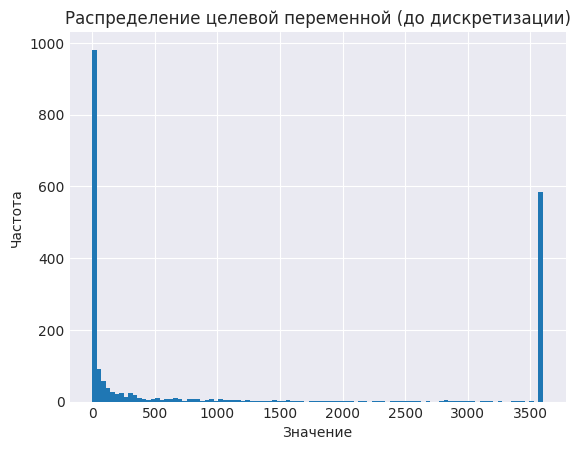

In [96]:
plt.hist(df_reg.target, 100)
plt.title("Распределение целевой переменной (до дискретизации)")
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.show()

Мы видим, что целевая переменная имеет численный вид (то есть перед нами проблема регрессии), и при этом, распределена очень неравномерно.

Это не красивое около-нормальное распределение из предыдущего примера. Это очень несбалансированное двухмодальное распределение. Есть большое количество объектов в датасете, у которых значение целевой переменной близко к 0, чуть меньшее, но тоже большое количество объектов, у которых оно близко к максимальному (порядка 3 500), и очень мало объектов с промежуточными значениями.

Такое странное неравномерное распределение может повлечь проблемы при моделировании. Проблема сходная с дисбалансом классов, но для регрессии. Модель будет при своем обучении очень часто видеть объекты со схожими значениями целевой переменной и очень редко - объекты с промежуточными. В итоге модель может не научиться распознавать такие промежуточные объекты. 

Покажем, как можно уменьшить влияние такого распределения. Но сначала разделим датасет на обучающую и тестовую выборки, чтобы отдельно обработать их уже после разделения:

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    df_reg.data, df_reg.target, test_size=0.25, random_state=42
)

Как мы уже упоминали, разделение датасета может внести случайные ошибки выборки, что особенно критично при неравномерных распределениях. Поэтому важно убедиться, что в обеих частях распределение сохранило свою форму, хотя бы в общих чертах:

![](https://github.com/koroteevmv/ML_course/blob/main/ML5.4%20target/img/ml54-7.png?raw=true)

Мы можем исправить неравномерность распределения разными способами, среди которых также ресемплирование выборки, как и в случае с классификацией. Но здесь покажем другой подход - дискретизацию целевой переменной. Этот способ заключается в том, что мы объединяем значения целевой переменной в категории - bins - поэтому такой способ часто называют биннинг. 

Группировать объекты можно опять же по-разному. Для автоматизации этой процедуры в библиотеке sklearn есть специальный объект - KBinsDiscretizer, который находится в пакете preprocessing. Воспользуемся им и создадим, например, пять групп:

In [98]:
y_binned_uniform = KBinsDiscretizer(
    n_bins=5, encode="ordinal", strategy="uniform"
).fit_transform(pd.DataFrame(y_train))

Группировка объектов означает, что мы переходим к категориальному типу в целевой переменной. Каждая категория будет обозначать некоторый диапазон исходных значений. При этом категории нумеруются последовательно, как при применении OrdinalEncoder при кодировании категориальных признаков. Но в этом случае, применение такой кодировки оправдано, так как эти категории, обозначая диапазоны значений численной шкалы, имеют естественный порядок.


In [99]:
print(repr(y_binned_uniform))

array([[4.],
       [0.],
       [4.],
       ...,
       [0.],
       [0.],
       [4.]], shape=(1581, 1))


Самая простая стратегия биннинга, которая применяется в этом объекте по умолчанию - равномерная. Она делит существующий диапазон значений на указанное количество равных по величине поддиапазонов, каждый из которых кодируется последовательным натуральным числом. По сути, мы просто укрупняем целевую переменную. Если раньше у нас было произвольно большое количество значений, потенциально равное количеству объектов в выборке, то после дискретизации остается указанное количество, в нашем примере - пять. Давайте визуализируем получившееся распределение:

Естественно, так как мы используем равномерные диапазоны, в крайних поддиапазонах соберутся большинство объектов выборки. Мы это видим на графике - столбцы укрупнились, но неравномерность распределения никуда не делась. В случае таких сильно неравномерных распределений нам больше подойдет другая стратегия - квантильная дискретизация, при которой длина диапазонов выбирается таким образом, чтобы в каждом из них оказалось примерно по одинаковому количеству объектов выборки.

Такой способ полностью исключит неравномерность распределения. На графике хорошо видно, что теперь каждой категории соответствует одинаковое количество объектов.

Обратите внимание, что на диаграмме четыре столбика, причем последний в два раза выше. Это всего лишь артефакт визуализации, в которой две последние категории объединились. Самостоятельно поэкспериментируйте с визуализацией и выберите такой график, который корректно показывает получившееся распределение.

In [100]:
y_binned_quantile = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile").fit_transform(pd.DataFrame(y_train))

/home/kai/ML_course/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/home/kai/ML_course/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


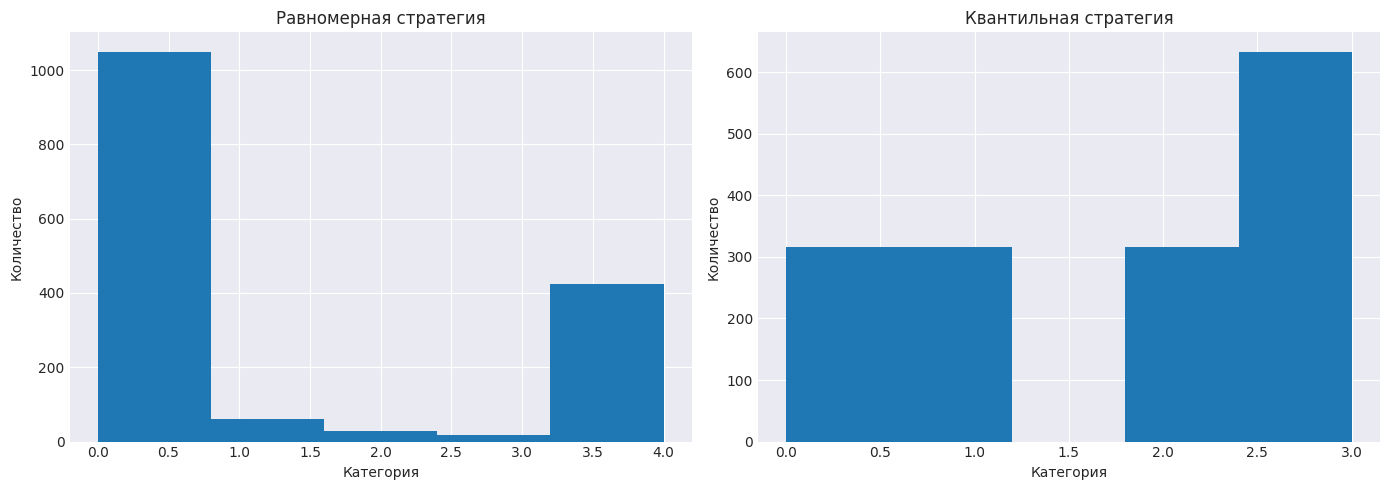

In [101]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(y_binned_uniform, bins=5)
plt.title("Равномерная стратегия")
plt.xlabel("Категория")
plt.ylabel("Количество")

plt.subplot(1, 2, 2)
plt.hist(y_binned_quantile, bins=5)
plt.title("Квантильная стратегия")
plt.xlabel("Категория")
plt.ylabel("Количество")

plt.tight_layout()
plt.show()

### Контрольные вопросы

**1. Какие модели лучше всего можно использовать для отбора признаков? Почему другие нельзя или нежелательно?**

Для отбора признаков лучше всего использовать модели, которые обладают свойством оценки важности признаков или интерпретируемостью коэффициентов. К таким моделям относятся случайный лес (имеет свойство feature_importances_), деревья решений, линейные модели с L1-регуляризацией (Lasso, логистическая регрессия с penalty='l1'), а также градиентный бустинг (XGBoost, LightGBM). Другие модели использовать нежелательно по следующим причинам: модели без интерпретируемости (нейронные сети) не дают прямого способа оценить вклад каждого признака; линейная регрессия без регуляризации даёт коэффициенты, чувствительные к масштабу и мультиколлинеарности; модели типа KNN не имеют обучаемых коэффициентов и не предоставляют информацию о важности признаков.

**2. Зачем нужен этап отбора признаков? В каких случаях без него не обойтись? А в каких его можно пропустить?**

Этап отбора признаков нужен для уменьшения переобучения, ускорения обучения и предсказания, улучшения интерпретируемости модели, снижения требований к памяти и вычислительным ресурсам, а также для устранения мультиколлинеарности. Без отбора признаков не обойтись в следующих случаях: когда количество признаков значительно превышает количество объектов (p >> n), когда большинство признаков являются шумовыми или не связаны с целевой переменной, при использовании моделей, чувствительных к размерности (линейная регрессия без регуляризации), а также когда интерпретируемость модели критически важна (медицина, финансы). Отбор признаков можно пропустить, когда используется модель, устойчивая к большому числу признаков (случайный лес, Lasso, Ridge), когда все признаки заведомо информативны и их немного, когда вычислительных ресурсов достаточно и интерпретируемость не важна, или при использовании глубокого обучения на больших данных.

**3. Какие есть методы отбора признаков? Найдите и опишите не менее пяти.**

Первый метод — удаление низкодисперсных признаков (VarianceThreshold). Удаляются признаки, у которых дисперсия ниже заданного порога, так как они почти не меняются между объектами и не несут информации. Второй метод — отбор по статистическим критериям (SelectKBest, SelectPercentile). Оценивается связь каждого признака с целевой переменной с помощью статистического теста (для регрессии — корреляция Пирсона или F-тест, для классификации — хи-квадрат или тест Фишера), и оставляются K лучших признаков. Третий метод — рекурсивное исключение признаков (RFE). Обучается модель, после чего удаляется признак с наименьшим коэффициентом или важностью, и процесс повторяется рекурсивно. Четвёртый метод — отбор на основе важности из модели (SelectFromModel). Обучается модель, поддерживающая оценку важности признаков (случайный лес, Lasso), после чего оставляются только признаки, важность которых превышает порог. Пятый метод — LASSO-регрессия (L1-регуляризация). Линейная модель с L1-штрафом обнуляет коэффициенты при неинформативных признаках, и признаки с ненулевыми коэффициентами считаются отобранными. Шестой метод — последовательный отбор (SFS). Итеративно либо добавляют признаки, которые максимально улучшают качество модели (forward), либо удаляют те, удаление которых меньше всего вредит качеству (backward).

**4. Какие есть стратегии устранения дисбаланса классов? В каких случаях стоит применять их и от чего зависит выбор стратегии?**

Существует пять основных стратегий устранения дисбаланса классов. Первая — взвешивание классов (class_weight): при обучении объектам миноритарного класса присваивается больший вес, модель сильнее штрафуется за ошибки на них. Это первый шаг, который стоит пробовать всегда. Вторая — оверсемплинг: увеличение количества объектов миноритарного класса путём дублирования или генерации новых объектов (простой оверсемплинг или SMOTE). Применяется, когда взвешивание не помогло или модель не поддерживает веса. Третья — андерсемплинг: уменьшение количества объектов мажоритарного класса путём случайного удаления. Применяется, когда данных очень много и вычислительные ресурсы ограничены. Четвёртая — генерация синтетических данных (SMOTE, ADASYN, Borderline-SMOTE). Применяется, когда нужно избежать переобучения от простого дублирования. Пятая — использование метрик, устойчивых к дисбалансу (precision, recall, F1-score, ROC-AUC, PR-AUC) вместо accuracy. Применяется всегда для корректной оценки независимо от выбранной стратегии. Выбор стратегии зависит от того, поддерживает ли модель веса классов, от размера датасета (при малом датасете оверсемплинг предпочтительнее), от степени дисбаланса (при очень сильном лучше комбинировать методы), а также от наличия вычислительных ресурсов.

**5. Какие модели машинного обучения из библиотеки sklearn поддерживают веса классов?**

В библиотеке sklearn параметр class_weight поддерживают следующие модели для классификации: LogisticRegression, SVC, RandomForestClassifier, DecisionTreeClassifier, GradientBoostingClassifier, RidgeClassifier, BaggingClassifier (через базовый классификатор), SGDClassifier. Для регрессии модели не имеют class_weight, но имеют параметр sample_weight в методе fit(), позволяющий задать вес для каждого объекта индивидуально. Модели наивного байесовского классификатора (GaussianNB, MultinomialNB) не поддерживают веса классов напрямую — для них нужно применять ресемплинг данных.

**6. Зачем использовать дискретизацию непрерывной целевой переменной? В каких случаях это оправданно, а в каких — нет?**

Дискретизация непрерывной целевой переменной используется для превращения регрессии в классификацию (когда предсказание категории осмысленнее точного числа), для борьбы с неравномерным распределением (когда большинство объектов сконцентрированы в узких диапазонах), для упрощения задачи (классификация часто стабильнее регрессии), для устойчивости к выбросам (экстремальные значения попадают в те же категории), а также для улучшения интерпретируемости (категории понятнее чисел). Это оправданно, когда целевая переменная имеет сильно неравномерное или мультимодальное распределение, когда точное численное предсказание не требуется (кредитный скоринг), когда в данных много шума, или когда интерпретируемость важнее точности. Это не оправданно, когда нужна высокая точность численного предсказания (прогноз курса, температуры), когда распределение целевой переменной близко к нормальному и регрессия работает хорошо, когда потеря информации о точном значении недопустима, или когда категории получаются слишком грубыми.

**7. Почему дискретизацию целевой переменной нужно делать только после разделения на тестовую и обучающую подвыборки? Что такое утечка данных?**

Дискретизацию целевой переменной нужно делать только после разделения на тестовую и обучающую выборки, потому что параметры дискретизации (границы диапазонов) должны определяться исключительно по обучающей выборке, а затем применяться к тестовой. Если сначала выполнить дискретизацию на всём датасете, а потом разделить, то информация из тестовой выборки повлияет на границы категорий, что исказит честную оценку качества модели. Утечка данных (data leakage) — это ситуация, когда при обучении модели используется информация, которая не была бы доступна при реальном использовании модели. В контексте дискретизации утечка происходит, когда границы категорий вычисляются с учётом тестовых данных. Другие примеры утечки данных: масштабирование (StandardScaler, MinMaxScaler) до разделения выборки, заполнение пропусков медианой или средним до разделения, отбор признаков (SelectKBest, RFE) на всём датасете — любая операция, которая вычисляет параметры по данным и применяется до разделения.